In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import linalg
import networkx as nx # 用于生成复杂的异质拓扑
from scipy.stats import ortho_group
from scipy import stats

In [2]:
def init_matrix_with_controlled_spectrum(N, distribution='uniform', bounds=(0.1, 1.0), symmetric=True):
    """
    初始化权重矩阵 W，并强制其精度矩阵 A = WW^T 具有特定的谱分布和增强的非对角相关性。

    Args:
        N (int): 维度。
        distribution (str): 谱分布类型 ('uniform', 'power_law', 'bimodal')。
        bounds (tuple): 特征值范围 (min, max)。
        symmetric (bool): True=对称W, False=非对称W (Dale兼容)。
        align_mean_mode (bool): 
            - True (关键修改): 强制第一个特征向量指向 [1,1...1]。这会将 lambda[0] 的能量
              广播到整个矩阵的非对角元，使 A_ij 的量级不再趋于 0。
            - False: 纯随机旋转，A_ij 通常为 O(1/sqrt(N))，远小于 A_ii。

    Returns:
        W (ndarray): 权重矩阵。
        A (ndarray): 精度矩阵。
    """
    # --- 1. 生成 A 的特征向量基 Q (Output Basis) ---

    # 原始逻辑：纯随机基 (导致 A 接近对角阵)
    if N < 1000:
        Q = ortho_group.rvs(N)
    else:
        H = np.random.randn(N, N)
        Q, _ = linalg.qr(H)

    # --- 2. 定义 A 的目标谱 (Eigenvalues) ---
    if distribution == 'orthogonal':
        lambdas = np.ones(N) # A = I
    
    elif distribution == 'uniform':
        low, high = bounds
        lambdas = np.random.uniform(low, high, N)
        
    elif distribution == 'power_law':
        # 幂律分布 (Sloppy Model 常用)
        alpha = 1.0
        x = np.random.uniform(0, 1, N)
        lambdas = (1 - x) ** (-1/alpha)
        # 映射到 bounds
        l_min, l_max = lambdas.min(), lambdas.max()
        lambdas = bounds[0] + (lambdas - l_min) * (bounds[1] - bounds[0]) / (l_max - l_min)
        
    elif distribution == 'bimodal':
        # 双峰分布：模拟 E-I 分离的强相互作用
        # 一半很强(Stiff)，一半很弱(Sloppy)
        mid = N // 2
        lambdas = np.zeros(N)
        lambdas[:mid] = np.random.uniform(bounds[0], bounds[0]*10, mid) # Sloppy
        lambdas[mid:] = np.random.uniform(bounds[1]/10, bounds[1], N-mid) # Stiff
        
    else:
        raise ValueError("Unknown distribution")


    # --- 3. 重构 W (Reconstruction) ---
    # A = Q * diag(lambda) * Q.T
    
    sqrt_lam = np.sqrt(lambdas)
    
    if symmetric:
        # W 是对称平方根
        W = Q @ np.diag(sqrt_lam) @ Q.T
    else:
        # W 是混合符号 (Mixed Signs)
        # 使用独立的随机基 V 作为输入空间
        if N < 1000:
            V = ortho_group.rvs(N)
        else:
            H_v = np.random.randn(N, N)
            V, _ = linalg.qr(H_v)
            
        W = Q @ np.diag(sqrt_lam) @ V.T
    
    return W

In [3]:
class TwoLayerNeuralField:
    def __init__(self, N, constraint_type='conv', kernel_size=5, alpha=0.05, C=100.0):
        self.N = N
        self.alpha = alpha  # Entropy/Anti-collapse
        self.C = C          # Trace constraint
        self.ctype = constraint_type
        
        if constraint_type == 'conv':
            # Learn only a small local kernel
            self.kernel = np.zeros(kernel_size)
            self.kernel[kernel_size//2] = 1.0
        else:
            # Full matrix + Mask
            self.W_full = np.eye(N)
            np.fill_diagonal(self.W_full, np.random.rand(N))

            # self.W_full = np.eye(N) * 0.5
            dist = np.fromfunction(lambda i, j: np.minimum(np.abs(i-j), N-np.abs(i-j)), (N, N))
            self.mask = (dist <= kernel_size // 2).astype(float)
            
        self.normalize_W()
        W = self.get_W()
        A_init = W @ W.T + np.eye(self.N) * 1e-6
        self.A_init=A_init

    def normalize_W(self):
        """Strictly enforce Tr(WW^T) = C"""
        W = self.get_W()
        current_tr = np.trace(W @ W.T)
        scale = np.sqrt(self.C / current_tr)
        if self.ctype == 'conv':
            self.kernel *= scale
        else:
            self.W_full *= scale

    def get_W(self):
        if self.ctype == 'conv':
            # Build circulant W from kernel
            W = np.zeros((self.N, self.N))
            k_full = np.zeros(self.N)
            ks = len(self.kernel)
            k_full[:ks//2+1] = self.kernel[ks//2:]
            k_full[-ks//2:] = self.kernel[:ks//2+1]
            for i in range(self.N):
                W[i] = np.roll(k_full, i)
            return W
        else:
            return self.W_full * self.mask

    def update_hebbian(self,v, lr):
        W = self.get_W()
        A = W @ W.T + np.eye(self.N) * 1e-6
        A_inv = np.linalg.inv(A)
        
        # # Hebbian Gradient: dL/dW = 2*(M + alpha*A_inv - beta*I)W
        # # beta is the dynamic pressure to maintain Trace
        # beta = np.trace((M + self.alpha * A_inv) @ (W @ W.T)) / self.C
        # grad_W = 2 * (M + self.alpha * A_inv - beta * np.eye(self.N)) @ W
        
        
        v_projected = v.T @ A @ v  # Scalar: v^T (WW^T) v

        beta = (v_projected + self.alpha * self.N) / self.C
        
        # 4. Calculate grad_W
        # (vv^T @ W) is equivalent to v @ (v^T @ W) which is more efficient: O(NK) instead of O(N^2K)
        term_M_W = v.reshape(-1, 1) @ (v.reshape(1, -1) @ W)
        term_Entropy_W = self.alpha * (A_inv @ W)
        term_Trace_W = beta * W
        
        grad_W = 2 * (term_M_W + term_Entropy_W - term_Trace_W)

        
        
        if self.ctype == 'conv':
            # Project back to kernel (average across diagonals)
            dk = np.zeros_like(self.kernel)
            ks = len(self.kernel)
            for i in range(ks):
                offset = i - ks//2
                dk[i] = np.mean(np.diag(grad_W, k=offset) if offset>=0 else np.diag(grad_W, k=self.N+offset))
            self.kernel += lr * dk
        else:
            self.W_full += lr * grad_W * self.mask
            
        self.normalize_W()

In [4]:
def get_gradients(N, mode='local'):
    x = np.linspace(0, 1, N)
    if mode == 'local':
        # 1. Localized: Only neurons near center care about s
        # return np.exp(-(x - 0.5)**2 / (2 * 0.05**2)).reshape(-1, 1)
        return np.sin(x * 0.5) * np.exp(-0.5 * (x / 15.0)**2) # High freq sensitivity
    
    elif mode == 'global_shift':
        # 2. Global: A wave-like gradient across all neurons
        return np.sin(2 * np.pi * x).reshape(-1, 1)
        # return np.exp(-0.5 * (x / 6.0)**2) # Low freq sensitivity
    
    elif mode == 'mean_field':
        # 3. Mean Field: All neurons care equally

        a=np.ones((N, 1))
        # a[:N//2]=-1
        return a#np.random.choice([1, -1], size=N)#np.ones((N, 1))
        # return np.linspace(0.9,1.0,N)

In [5]:
def calculate_xi_field_theory(A, N):
    """
    Corrected Ginzburg-Landau correlation length calculation.
    xi = sqrt(kappa / m^2)
    """
    # 1. Get eigenvalues and eigenvectors
    # We use eigh because A is symmetric
    vals, vecs = np.linalg.eigh(A)
    
    # Sort them just in case (eigh usually returns sorted)
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]
    
    # 2. Identify the 'Mass' (Soft Mode eigenvalue)
    # This is the precision gap. If A is singular, m2 -> 0
    m2 = vals[0]
    
    # 4. Compute Correlation Length
    # Use a small epsilon to avoid division by zero at the critical point
    epsilon = 1e-12
    xi = np.sqrt(1 / (m2 + epsilon))
    
    # 5. Finite Size Clipping
    # Physical xi cannot meaningfully exceed the system size N
    return min(xi, N)

In [6]:
# TODO： 这个函数画的关联长度和上面这个有啥不同？
def calculate_xi_fourier_method(A, N):
    """
    基于傅立叶谱（功率谱）计算相关长度。
    假设 A 是平稳高斯场，提取其第一行作为核。
    """
    # 1. 提取 A 的第一行（代表空间相互作用核）
    # 如果 A 不是完美的 Toeplitz，可以对所有行取平均以增强鲁棒性
    # kernel = A[0, :] 
    mid_row = A[N // 2, :]
    kernel = np.roll(mid_row, -(N // 2))
    
    
    # 2. 变换到频率空间 (Power Spectrum of Precision)
    # A_k 对应的是精度谱，C_k = 1/A_k 才是相关谱
    A_k = np.real(np.fft.fft(kernel))

    freqs = np.fft.fftfreq(N) * (2 * np.pi) # 转换为弧度频率
    
    # 3. 找到基态频率 (通常是 k=0，或者 A_k 最小的地方)
    idx_min = np.argmin(np.abs(A_k))
    m2 = A_k[idx_min]
    
    # 4. 计算曲率 kappa
    # 找到基态旁边的邻居频率点
    idx_neighbor = (idx_min + 1) % N
    delta_k_sq = (freqs[idx_neighbor] - freqs[idx_min])**2
    
    kappa = (A_k[idx_neighbor] - A_k[idx_min]) / delta_k_sq
    
    # 5. 计算相关长度
    xi = np.sqrt(np.abs(kappa / (m2 + 1e-12)))
    
    return min(xi, N)

In [7]:
result_dir='result/'
modes=['local','global_shift','mean_field']
N_arr=np.array([600])
C = 2e2
# H_weight=1e-3
H_weight = 0
topo='random'

constraint='mask'
# kernel_s = 10

In [8]:
A_arr=[]
W_arr=[]
Ai_arr=[]
Wi_arr=[]
for N in N_arr:
    kernel_s = N//10
    f_prime = get_gradients(N, mode=modes[1])
    model=model = TwoLayerNeuralField(N, constraint_type=constraint,kernel_size=kernel_s, alpha=H_weight, C=C)
    h_fisher, h_xi,h_xi_fft= [], [],[]
    for _ in range(600):
        W = model.get_W()
        A =  W @ W.T + np.eye(N)*1e-6
        fi=f_prime.T @ A @ f_prime
        h_fisher.append(fi.item())
        
        h_xi.append(calculate_xi_field_theory(A, N))
        h_xi_fft.append(calculate_xi_fourier_method(A, N))
                
        model.update_hebbian(f_prime, lr=0.001)
    
    A_arr.append(A)
    W_arr.append(model.get_W)
    Ai_arr.append(model.A_init)
    # Wi_arr.append(model.W_init)
    # np.save(result_dir+'A'+str(N)+'_mat.npy',A)




In [9]:
vals,_ =np.linalg.eigh(A)
dt=0.05
eigenvalues= 1-dt*np.sort(vals)[:100]
# print(vals,eigenvalues)

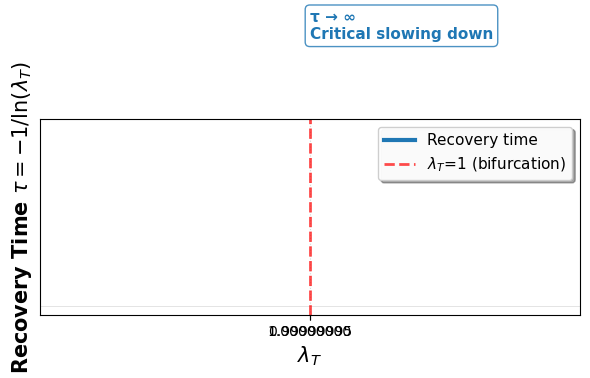

In [10]:
lam_scan = eigenvalues
recovery_time = -1 / np.log(lam_scan + 1e-10)  # 特征恢复时间

fig, ax2 = plt.subplots(figsize=(6, 4.5))

color1 = '#1f77b4'  # 蓝色
# Plot recovery time
ax2.plot(lam_scan, recovery_time, color='#1f77b4', linewidth=3, label='Recovery time')

# Reference lines
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax2.axvline(1, color='red', linestyle='--', linewidth=2, alpha=0.7, label=r'$\lambda_T$=1 (bifurcation)')

# Optimized annotation for the specific λ range
# Calculate position relative to your data range
lambda_min = min(lam_scan)
lambda_max = max(lam_scan)
lambda_range = lambda_max - lambda_min

# Place annotation at 75% of the range from min
# x_annotate = lambda_min + 0.75 * lambda_range
x_annotate = lambda_min + 0.75 * lambda_range
# Find corresponding recovery time at that λ
idx_annotate = np.argmin(np.abs(lam_scan - x_annotate))
y_annotate = recovery_time[idx_annotate]


ax2.annotate('τ → ∞\nCritical slowing down', 
            xy=(x_annotate, y_annotate), 
            xytext=(x_annotate, y_annotate * 1.5),
            # arrowprops=dict(arrowstyle='->', color='red', lw=2, connectionstyle="arc3,rad=0.1"),
            fontsize=11, color='#1f77b4' , fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='#1f77b4'))

# Customize x-ticks for your specific range
from matplotlib.ticker import FuncFormatter

def format_ticks(x, p):
    return f'{x:.8f}'

# # Generate ticks at meaningful positions
# tick_positions = [0.999996, 0.999997, 0.999998, 0.999999, 1.0]
# # Filter to only include ticks within your data range
# tick_positions = [t for t in tick_positions if t >= lambda_min - 0.0000005 and t <= lambda_max + 0.0000005]

tick_positions = [lambda_min,1.0]
ax2.set_xticks(tick_positions)
# 使用ScalarFormatter强制显示为小数
# x_formatter = ScalarFormatter(useOffset=False)
# x_formatter.set_scientific(False)  # 禁用科学计数法
# ax2.xaxis.set_major_formatter(x_formatter)
ax2.xaxis.set_major_formatter(FuncFormatter(format_ticks))
# ax2.tick_params(axis='x', rotation=45)  # Rotate for better readability

# Set x-axis limits with small padding
# ax2.set_xlim(lambda_min - 0.0000002, lambda_max + 0.0000002)

# Labels with math formatting
ax2.set_xlabel(r'$\lambda_T$', fontsize=15, fontweight='bold')
ax2.set_ylabel(r'Recovery Time $\tau = -1/\ln(\lambda_T)$', fontsize=15, fontweight='bold')
# ax2.set_xticks([])
ax2.set_yticks([])

# Legend
ax2.legend(fontsize=11, framealpha=0.95, fancybox=True, shadow=True)

# Grid with better styling
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax2.set_axisbelow(True)

# Add a zoomed inset if needed (optional)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Uncomment below if you want a zoomed view near λ=1
# axins = inset_axes(ax2, width="40%", height="40%", loc='upper left')
# axins.plot(lam_scan, recovery_time, 'r-', linewidth=2)
# axins.axvline(1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
# axins.set_xlim(0.999999, 1.0000001)
# axins.set_ylim(0, 200)
# axins.grid(True, alpha=0.2)
# mark_inset(ax2, axins, loc1=2, loc2=4, fc="none", ec="gray", linewidth=1)

plt.savefig(result_dir+f'critical_slowing_down_{modes[1]}.png',bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()